<h1> Feature Selection </h1>

So far, we have performed feature creation, but are all the features we’ve created actually useful for the model? After all, having a large number of features isn't always better.

Feature Selection means:

Selecting a subset of features that:

Contain the most information about the target</br>
Have less noise</br>
Lead to better model generalization

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

<h3> Step 1: Load Dataset </h3>

In [2]:
path = (
    "../../datasets/"
    "Titanic-Dataset/"
    "processed/"
    "titanic_feature_engineered.csv"
)

df = pd.read_csv(path)

df.head()

,Survived,Age,Fare,FamilySize,FarePerPerson,SibSp,Parch,Sex,Embarked,FamilyCategory,Title,Deck
0,0,22.0,7.2500,2,3.62500,1,0,male,S,Small,Mr,Unknown
1,1,38.0,71.2833,2,35.64165,1,0,female,C,Small,Mrs,C
2,1,26.0,7.9250,1,7.92500,0,0,female,S,Alone,Miss,Unknown
3,1,35.0,53.1000,2,26.55000,1,0,female,S,Small,Mrs,C
4,0,35.0,8.0500,1,8.05000,0,0,male,S,Alone,Mr,Unknown


<h3> Step 2: Seperating X and y

In [4]:
X = df.drop(
    "Survived",
    axis=1
)

y = df["Survived"]

print(X.shape)
print(y.shape)

(891, 11)
(891,)


<h3> Step 3: Feature Type Separation </h3>

Because the feature selection method depends on the type of feature.

Numerical

In [5]:
numeric_features = [
    "Age",
    "Fare",
    "FamilySize",
    "FarePerPerson",
    "SibSp",
    "Parch"
]

Categorical

In [6]:
categorical_features = [
    "Sex",
    "Embarked",
    "FamilyCategory",
    "Title",
    "Deck"
]

Numerical Correlation

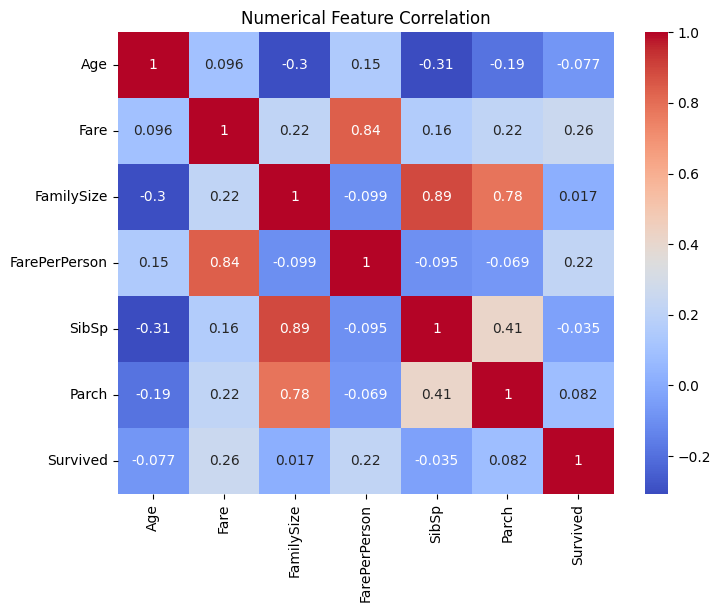

In [8]:
corr = df[
    numeric_features + ["Survived"]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Numerical Feature Correlation"
)

plt.show()

Correlation only captures linear relationships. For instance, if the relationship:

$X \rightarrow Y$ 

is non-linear, the correlation might be low. Therefore, we should not remove a feature based solely on this metric.

Here, we are asking:

Does the survival value change linearly as a feature increases or decreases?

We are not asking whether this feature is useful for predicting survival.

### Numerical Correlation Analysis

Pearson correlation was used to analyze linear relationships between numerical
features and the survival target.

Fare and FarePerPerson showed the strongest positive correlations with survival.
However, several features such as Age and FamilySize showed weak linear
correlations despite demonstrating meaningful relationships during exploratory
analysis.

This indicates that correlation alone cannot capture nonlinear relationships
or categorical effects. Therefore, additional feature selection techniques
including statistical tests and model-based importance methods are required.

<h3> Step 4: Categorical Feature Selection </h3>

Chi-Square Test

The Chi-Square test is used to examine the relationship between two categorical variables.

Here is our question:

Does the distribution of survival differ across the various categories of a feature?

An important point regarding Chi-Square:

Here, we only determine whether a relationship exists or not; Chi-Square does not indicate which feature is more important. To achieve better ranking, we need to use other methods.

In [10]:
def chi_square_test(
    data,
    feature,
    target="Survived"
):

    contingency_table = pd.crosstab(
        data[feature],
        data[target]
    )

    chi2, p, dof, expected = chi2_contingency(
        contingency_table
    )

    return chi2, p

In [11]:
categorical_features = [
    "Sex",
    "Embarked",
    "FamilyCategory",
    "Title",
    "Deck"
]

for feature in categorical_features:

    chi2, p = chi_square_test(
        df,
        feature
    )

    print(
        f"Feature: {feature}"
    )

    print(
        f"Chi-square: {chi2:.4f}"
    )

    print(
        f"p-value: {p:.6f}"
    )


    if p < 0.05:
        print(
            "Result: Significant relationship"
        )

    else:
        print(
            "Result: No significant relationship"
        )

    print("-"*40)

Feature: Sex
Chi-square: 260.7170
p-value: 0.000000
Result: Significant relationship
----------------------------------------
Feature: Embarked
Chi-square: 26.4891
p-value: 0.000002
Result: Significant relationship
----------------------------------------
Feature: FamilyCategory
Chi-square: 74.5372
p-value: 0.000000
Result: Significant relationship
----------------------------------------
Feature: Title
Chi-square: 283.3115
p-value: 0.000000
Result: Significant relationship
----------------------------------------
Feature: Deck
Chi-square: 99.1642
p-value: 0.000000
Result: Significant relationship
----------------------------------------


### Chi-Square Test for Categorical Features

Chi-square tests were applied to evaluate the dependency between categorical
features and the survival target.

All investigated categorical features showed statistically significant
relationships with survival (p < 0.05).

Among these features, Title and Sex demonstrated the strongest associations,
indicating that demographic information plays a major role in survival
prediction. FamilyCategory and Deck also provided meaningful information,
supporting the effectiveness of the performed feature engineering steps.

<h3> Step 5: Mutual Information (MI) </h3>

This step is very important because, unlike correlation and chi-square, it can also detect non-linear relationships.

The Concept of Mutual Information

The core question:

By how much does knowing the value of a feature reduce our uncertainty about the target?

In other words:

If we know the feature, how much more information do we have regarding survival?

Step 5.1: Data preparation

In [13]:
numeric_features = [
    "Age",
    "Fare",
    "FamilySize",
    "FarePerPerson",
    "SibSp",
    "Parch"
]

categorical_features = [
    "Sex",
    "Embarked",
    "FamilyCategory",
    "Title",
    "Deck"
]

Step 5.2: Numerical Mutual Information

In [14]:
mi_numeric = mutual_info_classif(
    df[numeric_features].fillna(
        df[numeric_features].median()
    ),
    df["Survived"],
    random_state=42
)

In [ ]:
numeric_mi = pd.DataFrame(
    {
        "Feature": numeric_features,
        "Mutual Information": mi_numeric
    }
)

numeric_mi.sort_values(
    by="Mutual Information",
    ascending=False
)

,Feature,Mutual Information
3,FarePerPerson,0.141633
1,Fare,0.138943
2,FamilySize,0.062978
5,Parch,0.033513
4,SibSp,0.023034
0,Age,0.000000


Step 5.3: Categorical Mutual Information

In [17]:
categorical_encoded = df[
    categorical_features
].copy()

for col in categorical_features:
    encoder = LabelEncoder()
    categorical_encoded[col] = encoder.fit_transform(
        categorical_encoded[col]
    )

In [18]:
mi_categorical = mutual_info_classif(
    categorical_encoded,
    df["Survived"],
    discrete_features=True,
    random_state=42
)

In [19]:
categorical_mi = pd.DataFrame(
    {
        "Feature": categorical_features,
        "Mutual Information": mi_categorical
    }
)

categorical_mi.sort_values(
    by="Mutual Information",
    ascending=False
)

,Feature,Mutual Information
3,Title,0.165706
0,Sex,0.150870
4,Deck,0.055122
2,FamilyCategory,0.042140
1,Embarked,0.016668


Step 5.4: Visualization

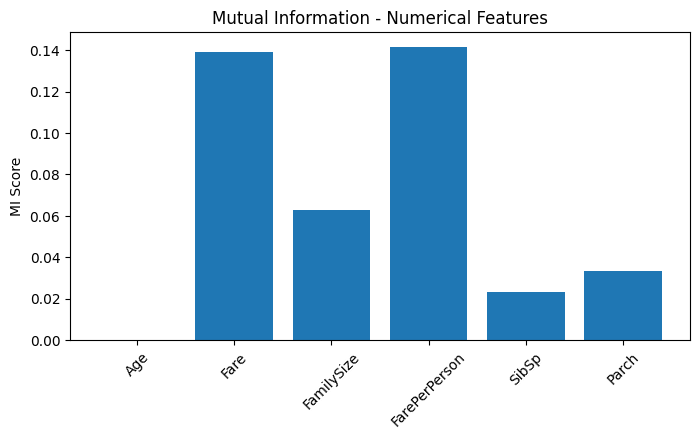

In [20]:
plt.figure(figsize=(8,4))

plt.bar(
    numeric_mi["Feature"],
    numeric_mi["Mutual Information"]
)

plt.xticks(
    rotation=45
)

plt.title(
    "Mutual Information - Numerical Features"
)

plt.ylabel(
    "MI Score"
)

plt.show()

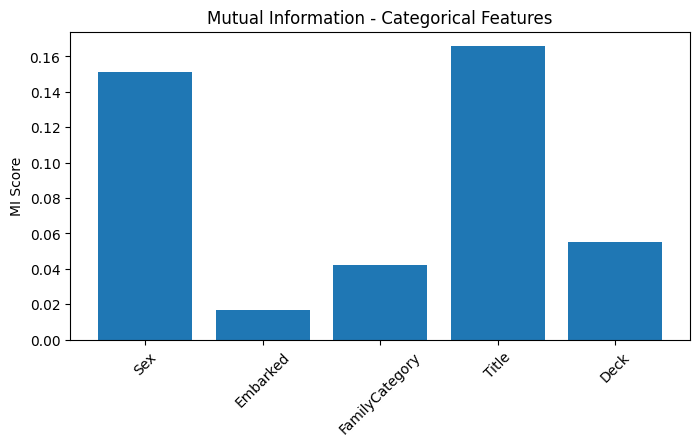

In [21]:
plt.figure(figsize=(8,4))

plt.bar(
    categorical_mi["Feature"],
    categorical_mi["Mutual Information"]
)

plt.xticks(
    rotation=45
)

plt.title(
    "Mutual Information - Categorical Features"
)

plt.ylabel(
    "MI Score"
)

plt.show()

MI values ​​are not directly comparable across all features if the calculation methods differ; however, they are highly suitable for ranking within a specific feature type.

### Mutual Information Analysis

Mutual Information was used to measure the amount of information provided by
each feature about the survival target.

Among numerical features, FarePerPerson and Fare showed the highest information
scores, indicating that economic status was an important factor in survival
prediction.

For categorical variables, Title and Sex provided the highest information
content. This confirms the importance of demographic features and validates
the feature engineering process.

Some features such as Age and Embarked showed lower mutual information scores;
however, they were not removed solely based on this analysis because feature
importance can vary depending on the learning algorithm.